In [12]:
import numpy as np
import math
import scipy.constants as const
import matplotlib.pyplot as plt

## Problem 10.3.7 decimal shift map

under: Ch 10 - 1D maps ("difference equations"). How to understand them, sometimes by translating techniques introduced in (continuous) differential equations

$$x_{n+1} = 10 x_n  \mod(1)$$

#### a) Draw the graph of the map

In [3]:
# wrapped into a function
def dec_shift_map(si, stop, show=False):
    '''si = initial condition
    stop = number of iterations'''
    # compute iteratively
    
    s = [si] # list of values... initialized only with the initial condition


    while len(s) < stop:
        s_mod = 10 * abs(s[-1]) # prepare 10x_n, where x_n is the last element in the list...
        s_next = s_mod - math.floor(s_mod) # ... to execute the mod(1) operation on it
        # I assume x_n+1 (x) = x_n+1 (-x)? you can ascribe the negative sign to the integer part anyway...
        s.append(s_next)
    
    # plot
    
    fig, ax = plt.subplots(1, 2, figsize=(20, 3))
    # 
    ax[0].plot(np.arange(len(s)), s, marker='o')
    ax[0].set(xlabel='$n$', ylabel='$x_n$', title='elements')
    ax[1].plot(s[:-1], s[1:], marker='o')
    ax[1].set(xlabel='$x_n$', ylabel='$x_{n+1}$', title='map')
    
    if show:
        return s

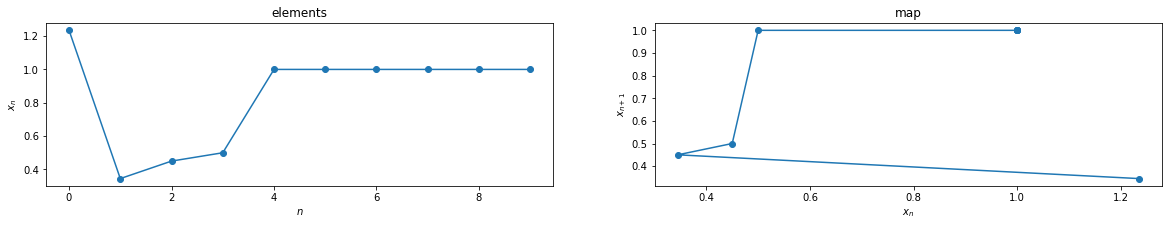

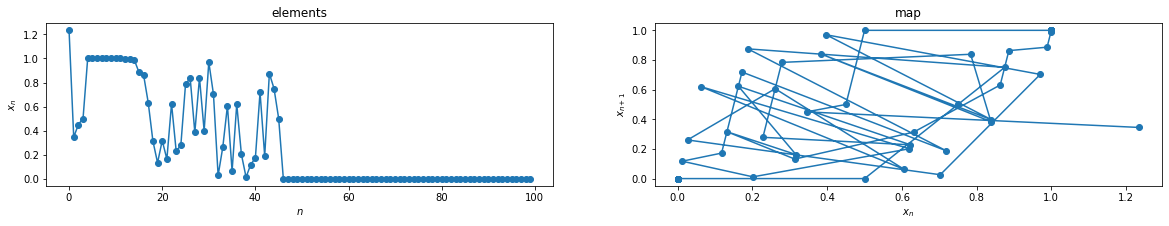

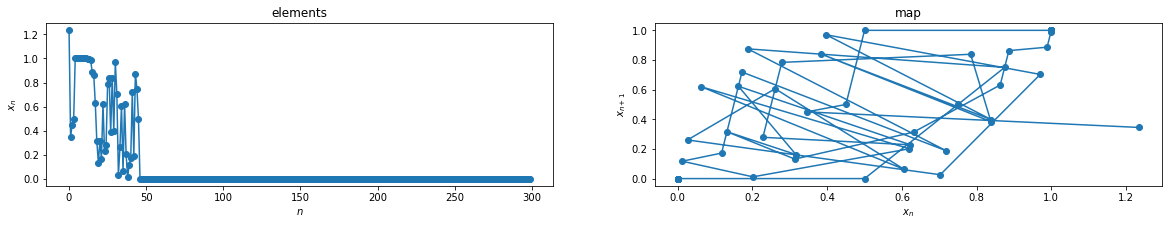

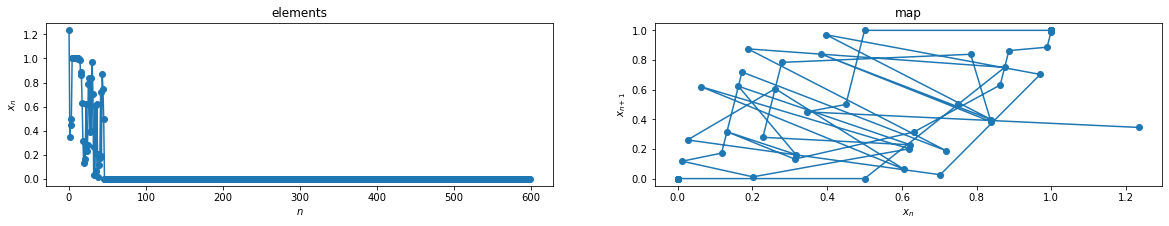

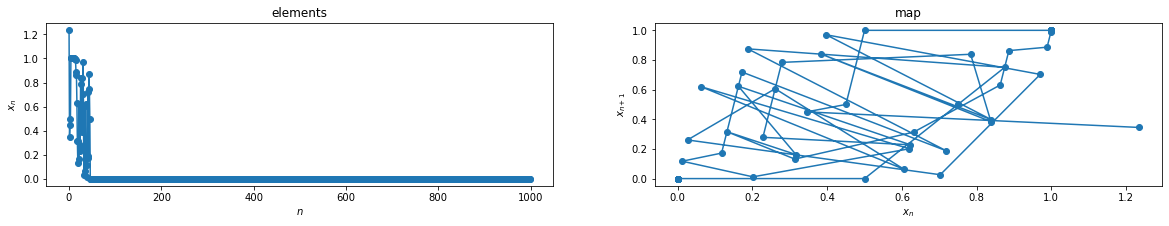

In [6]:
# investigate longer and longer iterations
dec_shift_map(si=1.2345, stop=10)
dec_shift_map(si=1.2345, stop=100)
dec_shift_map(si=1.2345, stop=300)
dec_shift_map(si=1.2345, stop=600)
dec_shift_map(si=1.2345, stop=1000)

Notice it goes to zero. Can you think why?
What does this operation do?
- discard integer (left of decimal point)
- take digits to the right of the integer
- (x 10) shift decimal point to the right once = shift one digit to the left of the decimal point
- repeat

In this sense, this operation "eats" the number from right to left. (I'll call it a piranha.) Eventually, if you provide a terminating number, the piranha will run out of digits to eat.

#### b) Find all the fixed points

That said, since a fixed point of the map is one where $x_{n+1} = x_n$ for all n, that would mean a number whose decimal digits are all the same.

In other words, this is a number that is non-terminating and with repeating digits. Notable examples are $m + 0.\bar{33} = g / 3$ where $m$ is an integer and $g$ is not a multiple of 3.

WHere else do repeating decimal places occur? Integers – because the digits to the right of the decimal point are all 0. Make the initial integer 0 – then the integer part is like its decimal part, thus **0 is another fixed point**.

Thus, these fixed points should show in the map as a single point.

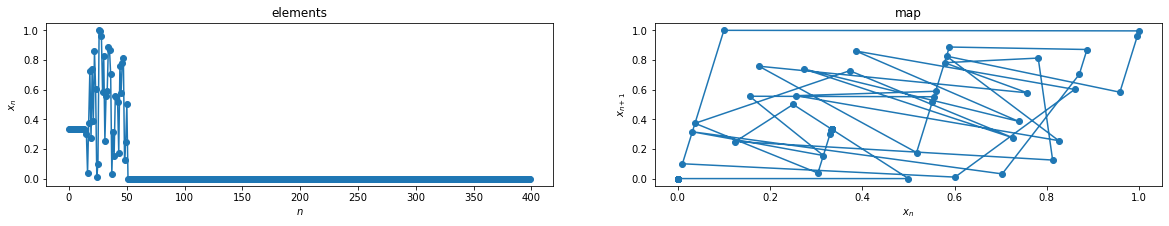

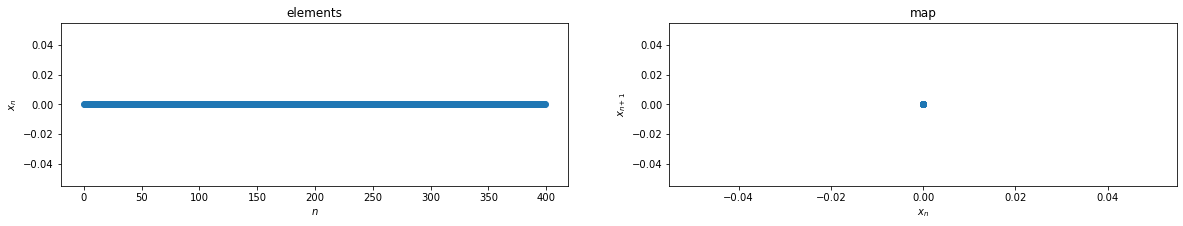

In [9]:
# investigate notable cases; test your guesses of fixed points

# repeating, non-terminating
dec_shift_map(si=1/3, stop=400) # wrong
dec_shift_map(si=0, stop=400) # ok

#### c) Show there are periodic periods of all points but they are unstable.

#### d) Show that the map has infinitely many aperiodic orbits.

Extending the previous venture to irrational numbers shows aperiodic orbits. THis is because, given our digit-eating algorithm, for the number portion to never be the same means that the digits should be nonrepeating.

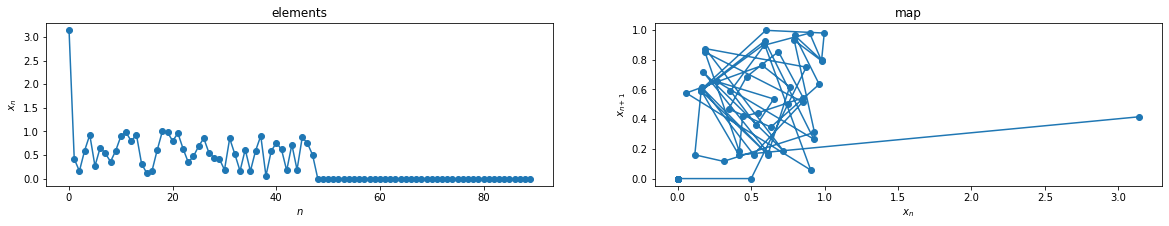

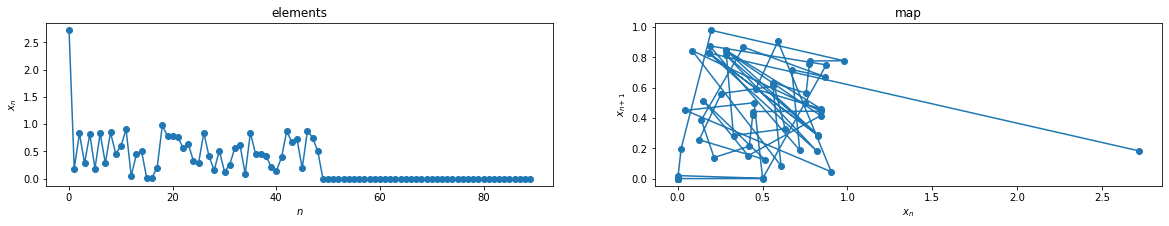

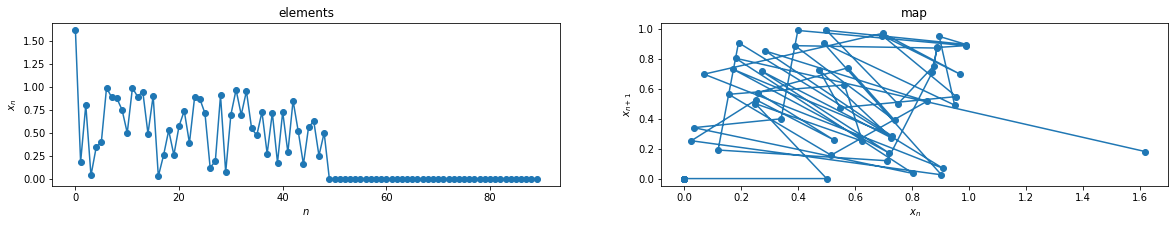

In [27]:
# irrational number – nonrepeating, non-terminating
dec_shift_map(si=math.pi, stop=90)
dec_shift_map(si=math.e, stop=90)
dec_shift_map(si=const.golden, stop=90)

# stick elements of a sequence together

Notice - although floating point precision of these imported constants is 16, setting a number of iterations well beyond it does not immediately put the map to zero. It is only at somwhere between 40 and 60 iterations that the map drops to 0. I can't see why...

One can make a number infinitely precise – in other words, keep specifying the digits after the decimal place... to the 400th decimal place, say.

#### e) By considering the rate of separation between two nearby orbits,  show that the map has sensitive dependence on initial conditions.

---

#### Scratch

[1.2345, 0.34499999999999886, 0.44999999999998863, 0.4999999999998863, 0.9999999999988631, 0.9999999999886313, 0.9999999998863132, 0.9999999988631316, 0.9999999886313162, 0.9999998863131623, 0.9999988631316228]


[Text(0.5, 0, '$x_n$'), Text(0, 0.5, '$x_{n+1}$')]

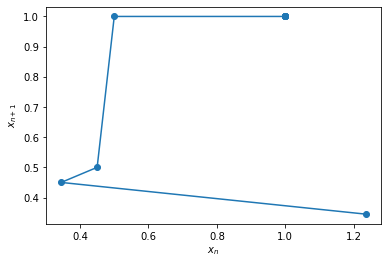

In [11]:
# initial draft of algorithm before I wrap it into a function

si = 1.2345 # initial condition

s = [si] # list of values... initialized only with the initial condition

stop = 10 # number of iterations

while len(s) <= stop:
    s_mod = 10 * abs(s[-1]) # prepare 10x_n...
    s_next = s_mod - math.floor(s_mod) # ... to execute the mod(1) operation
#     s.append(s[-1])
    s.append(s_next)

print(s)

# plot - FIX COBWEB

fig, ax = plt.subplots()
# ax.plot(s, s)
ax.plot(s[:stop], s[1:], marker='o')
ax.set(xlabel='$x_n$', ylabel='$x_{n+1}$')

---

(0.6180000000000003, 11.0)


[1.1618, 0.6179999999999986]

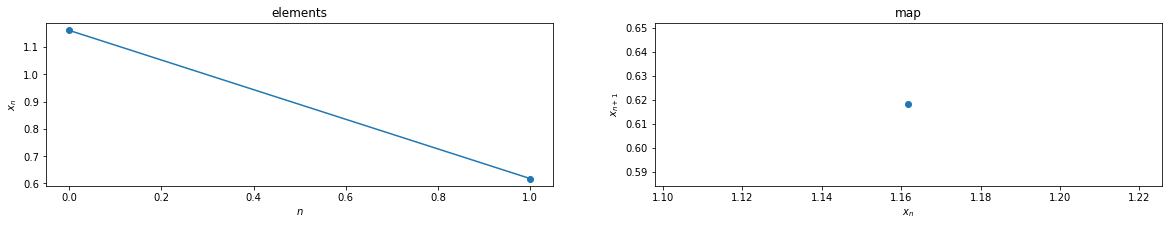

In [4]:
# scratch
# compare to a builtin mod 1 function if there is one
print(math.modf(11.618)) # first element of this tuple...
dec_shift_map(si=1.1618, stop=2, show=True) # vs 2nd element of this function (iteration)

Notice the builtin function adds digits that are not there, vs. my manual programming of `mod(1)` function.

---

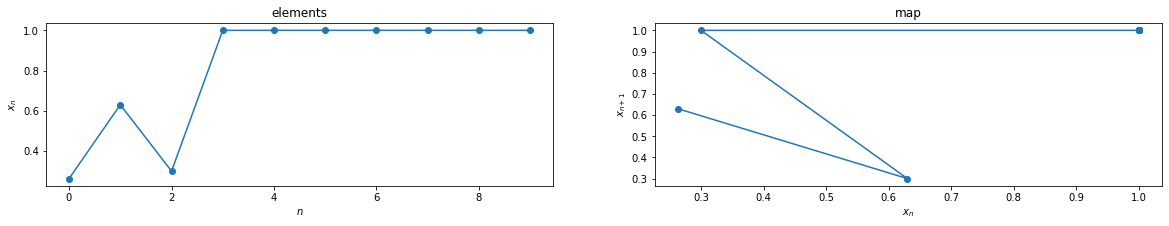

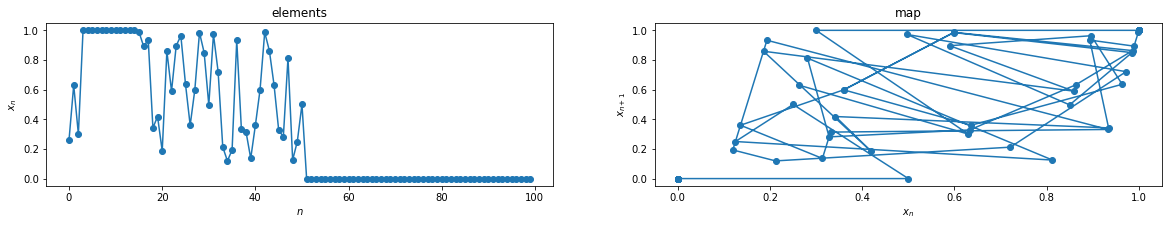

In [5]:
# the example in the problem: 2.63 mod(1) i.e. initial condition = 0.263
dec_shift_map(si=0.263, stop=10)
dec_shift_map(si=0.263, stop=100)

---

In [ ]:
# scratch
# number of iterations ≤ length of the irrational number encoded in Python, so that I can display its irrational nature.
# because an irrational number is really nonterminating but Python can't store a number that never ends.

len(f'{math.pi}') - 1 # -1 to exclude the decimal point in the character count
# 16

len(f'{math.e}') - 1
# 16 too

In [ ]:
const.find('ratio')